# AIR 파일럿 분석 — 추론·답변 불일치와 완화 이득 분해

**입력**: `records.csv` 한 파일 (문항 × 환경 평면 표). 생성·라벨링은 H100 서버에서 Qwen3.6-27B(bf16)로 수행했고,
이 노트북은 그 라벨 원자료만으로 지표를 **다시 계산**한다. 서버 의존 없이 Colab에서 그대로 실행된다.

| 컬럼 | 의미 |
|---|---|
| `item_id` | 문항 ID — 환경 간 짝짓기 키 |
| `dataset` | `ramdocs_a` (위키 합성 배치, misinformation 200) · `qacc` (실제 검색 스니펫, 138) · `dragged` (실제 검색 결과, 사실충돌 44 — 문서 라벨은 LLM 초벌+세션 내 검토, 한계 참조) |
| `env` | `standard` (대조군) · `reflection` (반추 프롬프트) · `standard_nothink` (사고 채널 off) |
| `L1` | 사고 트레이스가 충돌을 **언어화**했는가 (`detected` / `unrecognized`) |
| `L2` | 트레이스의 **마지막 명시적 문서 지지**가 정답 문서였는가 (`correct` / `wrong` / `unresolved`; L1 미탐지면 공란) |
| `FA` | 최종 답변 채점 (`correct` / `wrong` / `abstain`) |
| `path` | 정답의 4경로 귀속 (`legitimate` · `shortcut` · `discordant_hit` · `blind_hit`; 오답이면 공란) |
| `l2_source` | L2가 규칙(`rule`)/판정자(`judge`, gpt-oss-20b) 중 어느 쪽 판정인지 |
| `conflict_type` | 5유형 라벨 (`outdated` · `misinformation` · `conflicting_opinions` · `complementary` · `no_conflict`). RAMDocs는 원본 내장, QACC는 게이트① 판정자 2종 일치(128)+사전 규칙(12), DRAGged는 전문가 주석 |
| `type_recognition` | L1 탐지 건에서 **원인 유형까지 짚었는가** (`correct_type` / `surface_only` / 공란=미탐지) — RQ1 '유형 인지율'의 원자료 |

**지표 정의** (사전등록 그대로):
- Loss_L1 = P(L1 = unrecognized)
- Loss_L2 = P(L2 ≠ correct | L1 = detected)
- **AIR** = P(FA = wrong | L1 = detected, L2 = correct, 비기권) — 올바로 해소하고도 답변에서 뒤집힌 비율
- 4경로: 정답 중 `legitimate`(L1 탐지·L2 정답) · `shortcut`(탐지·미해소) · `discordant_hit`(탐지·오해소) · `blind_hit`(미탐지)
- 유효 분모 **N < 20**인 셀은 비율을 보고하지 않는다 (NaN). 데이터셋은 **합치지 않고 분리** 보고한다.

## 0. 준비 — 파일 찾기
`records.csv`를 현재 폴더 → `results/` → `/content` 순으로 찾고, 없으면 Colab 업로드 창을 연다. 서버 절대경로는 쓰지 않는다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)

def find_records():
    for p in [Path.cwd() / "records.csv", Path.cwd() / "results" / "records.csv",
              Path("/content/records.csv")]:
        if p.exists():
            return p
    from google.colab import files          # Colab 폴백 — 로컬 실행에서는 도달하지 않음
    up = files.upload()
    return Path(next(iter(up)))

path = find_records()
df = pd.read_csv(path, dtype=str, keep_default_na=False)
df["is_correct"] = df["is_correct"].astype(int); df["n_docs"] = df["n_docs"].astype(int)
print(f"loaded {path.name}: {len(df)} rows")
df.head()

loaded records.csv: 1146 rows


,item_id,dataset,env,seed,L1,L2,FA,path,is_correct,n_docs,conflict_type,l2_source,type_recognition
0,dragged-0012,dragged,reflection,13,detected,correct,correct,legitimate,1,10,outdated,judge,correct_type
1,dragged-0012,dragged,standard,13,detected,correct,correct,legitimate,1,10,outdated,judge,correct_type
2,dragged-0012,dragged,standard_nothink,13,unrecognized,,correct,blind_hit,1,10,outdated,,
3,dragged-0021,dragged,reflection,13,detected,correct,correct,legitimate,1,9,outdated,rule,correct_type
4,dragged-0021,dragged,standard,13,detected,correct,correct,legitimate,1,9,outdated,judge,surface_only


## 1. 기본 점검
셀(데이터셋 × 환경)별 문항 수와, 환경 간 `item_id` 집합이 같은지 확인한다. 전환 행렬은 같은 문항을 짝지어야 성립한다.

In [2]:
ENVS = ["standard", "reflection", "standard_nothink"]
# 데이터셋은 파일에 있는 것만 — RAMDocs·QACC에 DRAGged(사실충돌 44)가 추가될 수 있다
DATASETS = [d for d in ["ramdocs_a", "qacc", "dragged"] if d in set(df.dataset)]
print("datasets:", DATASETS)
print(df.groupby(["dataset", "env"]).item_id.nunique().unstack())
for ds in DATASETS:
    sets = {e: set(df[(df.dataset == ds) & (df.env == e)].item_id) for e in ENVS}
    print(ds, "item_id 집합 동일:", len({frozenset(s) for s in sets.values()}) == 1)
print("파싱 실패·기권:", (df.FA == "abstain").sum(), "건 기권")

datasets: ['ramdocs_a', 'qacc', 'dragged']
env        reflection  standard  standard_nothink
dataset                                          
dragged            44        44                44
qacc              138       138               138
ramdocs_a         200       200               200
ramdocs_a item_id 집합 동일: True
qacc item_id 집합 동일: True
dragged item_id 집합 동일: True
파싱 실패·기권: 0 건 기권


## 2. 지표 함수
사전등록 정의를 그대로 코드로 둔다. 조건부 비율은 **결합확률·분모 N**을 함께 내고, 문항 부트스트랩(2,000회, 시드 0)으로 95% CI를 붙인다. N < 20이면 값을 NaN으로 둔다.

In [3]:
MIN_N = 20
PATHS = ["legitimate", "shortcut", "discordant_hit", "blind_hit"]

def ratio(hits, mask, n_boot=2000, seed=0):
    """mask 위에서 hits 비율 + 부트스트랩 CI. 반환 (value, joint, n, lo, hi); N<MIN_N이면 value=NaN."""
    hits = np.asarray(hits, bool); mask = np.asarray(mask, bool)
    n = int(mask.sum())
    if n == 0:
        return (np.nan, np.nan, 0, np.nan, np.nan)
    vals = hits[mask].astype(float)
    v = vals.mean(); joint = vals.sum() / len(mask)
    rng = np.random.default_rng(seed)
    boots = np.sort([rng.choice(vals, n).mean() for _ in range(n_boot)])
    lo, hi = boots[int(0.025 * n_boot)], boots[int(0.975 * n_boot)]
    if n < MIN_N:
        v = np.nan
    return (v, joint, n, lo, hi)

def stage_metrics(g):
    l1 = (g.L1 == "detected").values; l2c = (g.L2 == "correct").values
    fa = g.FA.values; non_abs = fa != "abstain"
    m = {}
    m["Loss_L1"] = ratio(~l1, np.ones(len(g), bool))
    m["Loss_L2"] = ratio(~l2c, l1)
    m["AIR"] = ratio(fa == "wrong", l1 & l2c & non_abs)
    m["accuracy"] = ratio(fa == "correct", non_abs)
    m["abstain_rate"] = ratio(fa == "abstain", np.ones(len(g), bool))
    return m

def path_shares(g):
    correct = (g.FA == "correct").values
    return {p: ratio((g.path == p).values, correct) for p in PATHS}

## 3. 표 1 — 셀별 단계 손실·AIR·정확도
데이터셋별로 분리한다. `standard_nothink`는 사고 채널이 없어 L1은 정의상 전부 `unrecognized`이고 L2·AIR은 정의되지 않는다 — 그 셀에서 비교 가능한 것은 **정확도**뿐이다.

In [4]:
rows = []
for ds in DATASETS:
    for e in ENVS:
        g = df[(df.dataset == ds) & (df.env == e)]
        m = stage_metrics(g)
        rows.append({"dataset": ds, "env": e, "n_items": g.item_id.nunique(),
                     "accuracy": m["accuracy"][0], "Loss_L1": m["Loss_L1"][0],
                     "Loss_L2": m["Loss_L2"][0], "N_L2": m["Loss_L2"][2],
                     "AIR": m["AIR"][0], "N_AIR": m["AIR"][2],
                     "AIR_CI95": f"[{m['AIR'][3]:.3f}, {m['AIR'][4]:.3f}]" if m["AIR"][2] else "",
                     "abstain": int((g.FA == "abstain").sum())})
table1 = pd.DataFrame(rows).set_index(["dataset", "env"])
# nothink 셀: 트레이스 부재 → L1/L2/AIR 비교 불가(정의상) → 표시하지 않음
table1.loc[(slice(None), "standard_nothink"), ["Loss_L1", "Loss_L2", "AIR", "AIR_CI95"]] = np.nan
table1.round(3)

n_items  accuracy  Loss_L1  Loss_L2  N_L2    AIR  N_AIR        AIR_CI95  abstain
dataset   env                                                                                               
ramdocs_a standard              200     0.840    0.445    0.252   111  0.060     83  [0.012, 0.120]        0
          reflection            200     0.880    0.070    0.242   186  0.092    141  [0.050, 0.149]        0
          standard_nothink      200     0.940      NaN      NaN     0    NaN      0             NaN        0
qacc      standard              138     0.703    0.761    0.091    33  0.233     30  [0.100, 0.400]        0
          reflection            138     0.732    0.036    0.165   133  0.270    111  [0.189, 0.351]        0
          standard_nothink      138     0.790      NaN      NaN     0    NaN      0             NaN        0
dragged   standard               44     0.773    0.523    0.143    21    NaN     18  [0.056, 0.444]        0
          reflection             44     0.795    0.068    0.073    41  0.237     38  [0.105, 0.368]        0
          standard_nothink       44     0.841      NaN      NaN     0    NaN      0             NaN        0

## 4. 표 2 · 그림 1 — 정답의 4경로 분해
정답(FA = correct) 중 어떤 경로로 맞혔는지. `blind_hit`은 충돌을 언어화하지 않고 맞힌 것, `legitimate`만이 "인지→해소→표출"이 모두 이어진 정답이다.

                            n_correct  legitimate  shortcut  discordant_hit  blind_hit
dataset   env                                                                         
ramdocs_a standard                168          78         5              14         71
          reflection              176         128        14              24         10
          standard_nothink        188           0         0               0        188
qacc      standard                 97          23         0               3         71
          reflection              101          81         5              11          4
          standard_nothink        109           0         0               0        109
dragged   standard                 34          14         0               2         18
          reflection               35          29         1               2          3
          standard_nothink         37           0         0               0         37
                            legitimate_shar

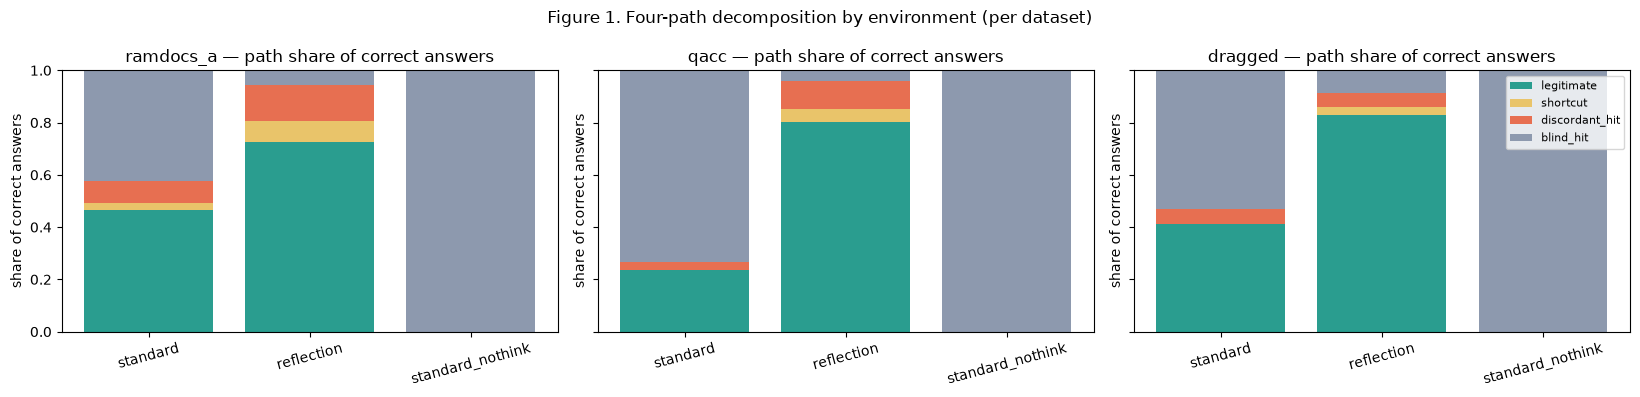

In [5]:
rows = []
for ds in DATASETS:
    for e in ENVS:
        g = df[(df.dataset == ds) & (df.env == e)]
        n_corr = int((g.FA == "correct").sum())
        r = {"dataset": ds, "env": e, "n_correct": n_corr}
        for p in PATHS:
            r[p] = int((g.path == p).sum())
            r[p + "_share"] = round(r[p] / n_corr, 3) if n_corr else np.nan
        rows.append(r)
table2 = pd.DataFrame(rows).set_index(["dataset", "env"])
print(table2[["n_correct"] + PATHS])
print(table2[[p + "_share" for p in PATHS]])

fig, axes = plt.subplots(1, len(DATASETS), figsize=(5.5 * len(DATASETS), 4), sharey=True)
axes = np.atleast_1d(axes)
colors = {"legitimate": "#2a9d8f", "shortcut": "#e9c46a", "discordant_hit": "#e76f51", "blind_hit": "#8d99ae"}
for ax, ds in zip(axes, DATASETS):
    sub = table2.loc[ds]
    bottom = np.zeros(len(ENVS))
    for p in PATHS:
        vals = sub.loc[ENVS, p + "_share"].values
        ax.bar(ENVS, vals, bottom=bottom, label=p, color=colors[p])
        bottom += vals
    ax.set_title(f"{ds} — path share of correct answers")
    ax.set_ylim(0, 1); ax.set_ylabel("share of correct answers")
    ax.tick_params(axis="x", rotation=15)
axes[-1].legend(loc="upper right", fontsize=8)
plt.suptitle("Figure 1. Four-path decomposition by environment (per dataset)")
plt.tight_layout(); plt.show()

## 5. 표 3 · 그림 2 — 전환 행렬 (standard → reflection / standard_nothink)
같은 문항을 짝지어 상태가 어떻게 움직였는지. 상태 = 정답이면 경로(4종), 오답·기권이면 FA 라벨. 시드가 1개라 문항 내 안정성 플래그는 없다.


=== ramdocs_a: standard → reflection (paired N=200) ===  rows=before, cols=after
col_0           legitimate  shortcut  discordant_hit  blind_hit  wrong  abstain
row_0                                                                          
legitimate              63         4               7          3      1        0
shortcut                 1         4               0          0      0        0
discordant_hit           6         2               6          0      0        0
blind_hit               50         2              10          7      2        0
wrong                    8         2               1          0     21        0
abstain                  0         0               0          0      0        0

=== ramdocs_a: standard → standard_nothink (paired N=200) ===  rows=before, cols=after
col_0           legitimate  shortcut  discordant_hit  blind_hit  wrong  abstain
row_0                                                                          
legitimate               0    

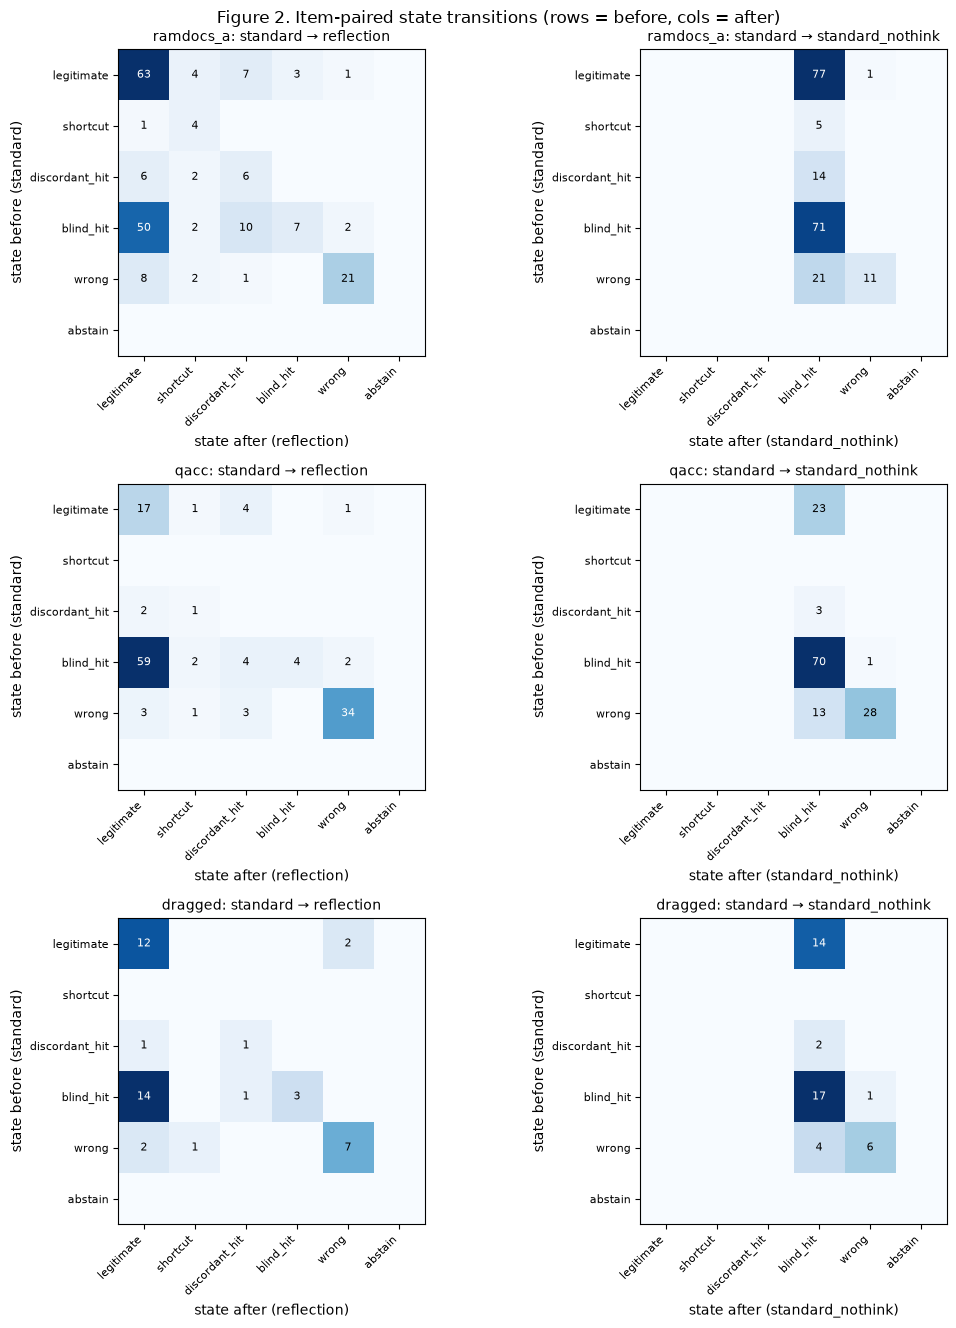

In [6]:
def state(r):
    return r.path if r.FA == "correct" else r.FA

piv = {}
for ds in DATASETS:
    for after in ["reflection", "standard_nothink"]:
        b = df[(df.dataset == ds) & (df.env == "standard")].set_index("item_id")
        a = df[(df.dataset == ds) & (df.env == after)].set_index("item_id")
        common = b.index.intersection(a.index)
        sb = b.loc[common].apply(state, axis=1); sa = a.loc[common].apply(state, axis=1)
        order = PATHS + ["wrong", "abstain"]
        ct = pd.crosstab(sb, sa).reindex(index=order, columns=order, fill_value=0)
        piv[(ds, after)] = ct
        print(f"\n=== {ds}: standard → {after} (paired N={len(common)}) ===  rows=before, cols=after")
        print(ct)

fig, axes = plt.subplots(len(DATASETS), 2, figsize=(11, 4.5 * len(DATASETS)))
for ax, ((ds, after), ct) in zip(np.atleast_2d(axes).ravel(), piv.items()):
    im = ax.imshow(ct.values, cmap="Blues")
    ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index, fontsize=8)
    for i in range(ct.shape[0]):
        for j in range(ct.shape[1]):
            v = ct.values[i, j]
            if v: ax.text(j, i, v, ha="center", va="center", fontsize=8,
                          color="white" if v > ct.values.max() / 2 else "black")
    ax.set_title(f"{ds}: standard → {after}", fontsize=10)
    ax.set_xlabel(f"state after ({after})"); ax.set_ylabel("state before (standard)")
plt.suptitle("Figure 2. Item-paired state transitions (rows = before, cols = after)")
plt.tight_layout(); plt.show()

## 6. 표 4 — 완화 이득 분해: LGR · HR · Flip
- **LGR** (Legitimate Gain Ratio) = 새로 정답이 된 문항 중 `legitimate` 경로로 맞힌 비율 — 이득이 진짜 대조 추론에서 왔는가
- **HR** (Hidden Regression) = 원래 `legitimate` 정답이던 문항이 오답·기권으로 무너진 비율
- **Flip** = 정답↔오답이 뒤집힌 문항 비율 (전체 짝 대비)

분모(N)가 20 미만이면 값을 내지 않는다 — 기저 정확도가 높아 "새로 맞은 문항" 자체가 적으면 LGR은 정의되기 어렵다.

In [7]:
CORRECT = set(PATHS)
rows = []
for (ds, after), ct in piv.items():
    flows = {(s, t): int(ct.loc[s, t]) for s in ct.index for t in ct.columns}
    new = {k: n for k, n in flows.items() if k[0] not in CORRECT and k[1] in CORRECT}
    n_new = sum(new.values()); n_new_legit = sum(n for (s, t), n in new.items() if t == "legitimate")
    was_legit = {k: n for k, n in flows.items() if k[0] == "legitimate"}
    n_legit = sum(was_legit.values()); n_reg = sum(n for (s, t), n in was_legit.items() if t not in CORRECT)
    n_flip = sum(n for (s, t), n in flows.items() if (s in CORRECT) != (t in CORRECT))
    n_tot = sum(flows.values())
    f = lambda a, b: (a / b if b >= MIN_N else np.nan)
    rows.append({"dataset": ds, "after": after, "paired": n_tot,
                 "newly_correct": n_new, "LGR": f(n_new_legit, n_new),
                 "legit_before": n_legit, "HR": f(n_reg, n_legit),
                 "flips": n_flip, "Flip": f(n_flip, n_tot),
                 "acc_before": sum(n for (s, t), n in flows.items() if s in CORRECT) / n_tot,
                 "acc_after": sum(n for (s, t), n in flows.items() if t in CORRECT) / n_tot})
table4 = pd.DataFrame(rows).set_index(["dataset", "after"])
table4.round(3)

paired  newly_correct  LGR  legit_before     HR  flips   Flip  acc_before  acc_after
dataset   after                                                                                                 
ramdocs_a reflection           200             11  NaN            78  0.013     14  0.070       0.840      0.880
          standard_nothink     200             21  0.0            78  0.013     22  0.110       0.840      0.940
qacc      reflection           138              7  NaN            23  0.043     10  0.072       0.703      0.732
          standard_nothink     138             13  NaN            23  0.000     14  0.101       0.703      0.790
dragged   reflection            44              3  NaN            14    NaN      5  0.114       0.773      0.795
          standard_nothink      44              4  NaN            14    NaN      5  0.114       0.773      0.841

## 7. 그림 3 — AIR (95% CI) · 그림 4 — 환경별 정확도
AIR은 유효 분모(N)와 함께 읽는다. 그림 4는 사고 채널 on/off를 같은 가중치에서 토글한 정확도 대조를 포함한다.

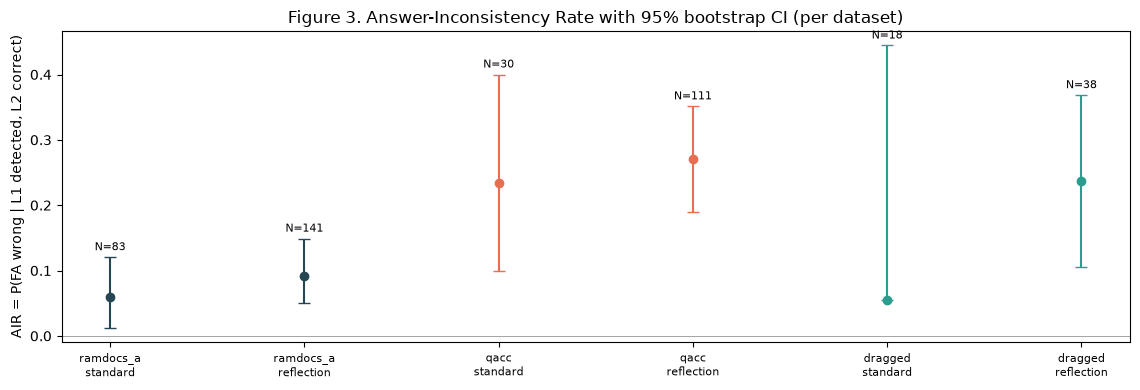

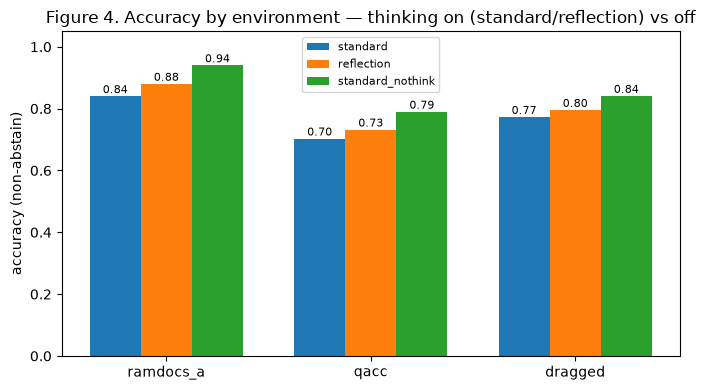

In [8]:
fig, ax = plt.subplots(figsize=(3.5 * len(DATASETS) + 1, 4))
x = 0
ticks, labels = [], []
for ds in DATASETS:
    for e in ["standard", "reflection"]:
        m = stage_metrics(df[(df.dataset == ds) & (df.env == e)])["AIR"]
        v, _, n, lo, hi = m
        if n:
            ax.errorbar(x, v if not np.isnan(v) else lo, yerr=[[max(0, (v if not np.isnan(v) else lo) - lo)], [hi - (v if not np.isnan(v) else lo)]],
                        fmt="o", capsize=4, color={"ramdocs_a": "#264653", "qacc": "#e76f51", "dragged": "#2a9d8f"}.get(ds, "gray"))
            ax.annotate(f"N={n}", (x, hi), textcoords="offset points", xytext=(0, 5), ha="center", fontsize=8)
        ticks.append(x); labels.append(f"{ds}\n{e}"); x += 1
ax.set_xticks(ticks); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("AIR = P(FA wrong | L1 detected, L2 correct)")
ax.set_title("Figure 3. Answer-Inconsistency Rate with 95% bootstrap CI (per dataset)")
ax.axhline(0, color="gray", lw=0.5); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
w = 0.25
for i, e in enumerate(ENVS):
    accs = [stage_metrics(df[(df.dataset == ds) & (df.env == e)])["accuracy"][0] for ds in DATASETS]
    ax.bar(np.arange(len(DATASETS)) + (i - 1) * w, accs, w, label=e)
    for j, a in enumerate(accs):
        ax.text(j + (i - 1) * w, a + 0.01, f"{a:.2f}", ha="center", fontsize=8)
ax.set_xticks(range(len(DATASETS))); ax.set_xticklabels(DATASETS)
ax.set_ylim(0, 1.05); ax.set_ylabel("accuracy (non-abstain)")
ax.set_title("Figure 4. Accuracy by environment — thinking on (standard/reflection) vs off")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 8. 표 5 — 충돌 유형별 층화 · 유형 인지율
연구보고 §3.1(5유형 축)·§3.3(RQ1 지표) 대로 **충돌 유형별로 갈라** 본다. 유형 인지율 = 유형 적중 충돌문항 / 전체 충돌문항 (L1 미탐지는 미적중으로 센다). N < 20인 층은 비율을 비우고 개수만 남긴다 — 파일럿 표본에서는 `misinformation` 외 층이 대부분 여기에 해당한다.

In [9]:
rows = []
for ds in DATASETS:
    for e in ENVS:
        g_env = df[(df.dataset == ds) & (df.env == e)]
        for ct, g in g_env.groupby("conflict_type"):
            m = stage_metrics(g)
            n = len(g)
            rows.append({"dataset": ds, "env": e, "conflict_type": ct, "n": n,
                         "accuracy": m["accuracy"][0],
                         "L1_detected": int((g.L1 == "detected").sum()),
                         "type_rec_rate": (round((g.type_recognition == "correct_type").mean(), 3) if n >= MIN_N else np.nan),
                         "AIR": m["AIR"][0], "N_AIR": m["AIR"][2],
                         "legitimate": int((g.path == "legitimate").sum()), "blind_hit": int((g.path == "blind_hit").sum())})
table5 = pd.DataFrame(rows).set_index(["dataset", "env", "conflict_type"])
table5.loc[(slice(None), "standard_nothink", slice(None)), ["type_rec_rate", "AIR"]] = np.nan
table5.round(3)

n  accuracy  L1_detected  type_rec_rate    AIR  N_AIR  legitimate  blind_hit
dataset   env              conflict_type                                                                                 
ramdocs_a standard         misinformation  200     0.840          111          0.010  0.060     83          78         71
          reflection       misinformation  200     0.880          186          0.025  0.092    141         128         10
          standard_nothink misinformation  200     0.940            0            NaN    NaN      0           0        188
qacc      standard         misinformation  120     0.725           29          0.017  0.192     26          21         63
                           outdated         18       NaN            4            NaN    NaN      4           2          8
          reflection       misinformation  120     0.742          118          0.000  0.275    102          74          1
                           outdated         18       NaN           15            NaN    NaN      9           7          3
          standard_nothink misinformation  120     0.783            0            NaN    NaN      0           0         94
                           outdated         18       NaN            0            NaN    NaN      0           0         15
dragged   standard         misinformation    3       NaN            2            NaN    NaN      2           2          1
                           outdated         41     0.756           19          0.366    NaN     16          12         17
          reflection       misinformation    3       NaN            2            NaN    NaN      2           1          1
                           outdated         41     0.805           39          0.805  0.222     36          28          2
          standard_nothink misinformation    3       NaN            0            NaN    NaN      0           0          3
                           outdated         41     0.829            0            NaN    NaN      0           0         34

## 9. 보조 — L2 판정 출처 민감도 (규칙만 vs 규칙+판정자)
L2는 규칙이 명시적 문서 지지를 못 찾은 건만 판정자(gpt-oss-20b)에게 넘긴 하이브리드다. 판정자 판정을 `unresolved`로 되돌리면 AIR 분모가 얼마나 줄고 값이 어떻게 움직이는지 — 라벨링 방식이 결론을 만들지 않는지 점검.

In [10]:
rows = []
for ds in DATASETS:
    for e in ["standard", "reflection"]:
        g = df[(df.dataset == ds) & (df.env == e)].copy()
        full = stage_metrics(g)["AIR"]
        g_rule = g.copy(); g_rule.loc[g_rule.l2_source == "judge", "L2"] = "unresolved"
        rule = stage_metrics(g_rule)["AIR"]
        rows.append({"dataset": ds, "env": e, "judge_labeled_L2": int((g.l2_source == "judge").sum()),
                     "AIR_rule_only": rule[0], "N_rule_only": rule[2],
                     "AIR_with_judge": full[0], "N_with_judge": full[2]})
pd.DataFrame(rows).set_index(["dataset", "env"]).round(3)

judge_labeled_L2  AIR_rule_only  N_rule_only  AIR_with_judge  N_with_judge
dataset   env                                                                                   
ramdocs_a standard                  51          0.068           44           0.060            83
          reflection               117          0.021           47           0.092           141
qacc      standard                  26            NaN            6           0.233            30
          reflection                83          0.242           33           0.270           111
dragged   standard                  12            NaN            7             NaN            18
          reflection                24            NaN           15           0.237            38

## 10. 읽는 법 (요약)
- 표 1·그림 3: AIR과 그 분모. 데이터셋별로 따로 본다 — 합치지 않는다.
- 표 2·그림 1: 정답이 어떤 경로로 왔는가. `legitimate` 비중이 낮고 `blind_hit`이 높으면 "맞혔지만 충돌을 다루지 않은" 정답이 많다는 뜻.
- 표 3·4, 그림 2: `reflection`이 상태를 어떻게 움직였는가. 정확도 차이가 작아도 L1(언어화)과 경로 구성이 크게 바뀔 수 있다. LGR은 새로 맞은 문항이 적으면 정의되지 않는다(N 표기).
- 그림 4: 사고 채널을 끈 `standard_nothink` 정확도는 "추론 채널이 정답률에 기여했는가"의 인과 대조.
- 표 5: 유형별 층화와 유형 인지율(RQ1 두 번째 지표). 파일럿은 사실충돌(outdated·misinformation) 위주라 유형 간 비교는 `misinformation` 층 외엔 N<20이다.
- 한계: 시드 1개(문항 내 안정성 미산출), 판정자 1종(옵션 스왑 미적용), QACC 판정 불일치 66문항 제외. DRAGged 문서 라벨은 규약상 '사람 검토'가 아니라 gpt-oss 초벌 + 이 세션의 Claude 검토(κ=0.885, N=143)로 확정한 것이라 사람 재검토 전까지 예비 결과로 읽어야 한다.